# Lab Assignment 4: Logistic Regression on Breast Cancer Wisconsin Dataset


---

### Objective
This lab assignment focuses on building, evaluating, and interpreting a Logistic Regression model for binary classification using the Breast Cancer Wisconsin (Diagnostic) dataset. The tasks cover data exploration, feature scaling, model training, performance metric analysis, and medical diagnostic interpretations.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('muted')


## Task 1: Data Acquisition and Exploration

### 1. Download and Load the Dataset
We load the Breast Cancer Wisconsin (Diagnostic) dataset from `datasets/breast_cancer.csv`.  
The target variable `Outcome` is binary encoded as:
- `1` = Malignant (cancerous)
- `0` = Benign (non-cancerous)


In [2]:
# Load dataset from local datasets directory
dataset_path = 'datasets/breast_cancer.csv'
df = pd.read_csv(dataset_path)

print(f"Dataset Loaded Successfully from: {dataset_path}")
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset Loaded Successfully from: datasets/breast_cancer.csv
Dataset Dimensions: 569 rows, 31 columns


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### 2. Compute Summary Statistics
Summary statistics (mean, median, standard deviation, min, max, 25%, 75%) for all numeric features.


In [3]:
# Calculate summary statistics
stats_summary = df.describe().T
stats_summary['median'] = df.median()

# Reorder columns for readability
ordered_cols = ['mean', 'std', 'median', 'min', '25%', '50%', '75%', 'max']
stats_summary = stats_summary[ordered_cols]
stats_summary.round(3)


,mean,std,median,min,25%,50%,75%,max
mean radius,14.127,3.524,13.370,6.981,11.700,13.370,15.780,28.110
mean texture,19.290,4.301,18.840,9.710,16.170,18.840,21.800,39.280
mean perimeter,91.969,24.299,86.240,43.790,75.170,86.240,104.100,188.500
mean area,654.889,351.914,551.100,143.500,420.300,551.100,782.700,2501.000
mean smoothness,0.096,0.014,0.096,0.053,0.086,0.096,0.105,0.163
mean compactness,0.104,0.053,0.093,0.019,0.065,0.093,0.130,0.345
mean concavity,0.089,0.080,0.062,0.000,0.030,0.062,0.131,0.427
mean concave points,0.049,0.039,0.034,0.000,0.020,0.034,0.074,0.201
mean symmetry,0.181,0.027,0.179,0.106,0.162,0.179,0.196,0.304
mean fractal dimension,0.063,0.007,0.062,0.050,0.058,0.062,0.066,0.097


### 3. Check for Missing Values, Duplicates, and Outliers


In [4]:
# Missing values and duplicate rows check
missing_count = df.isnull().sum().sum()
duplicate_count = df.duplicated().sum()

print(f"Missing Values Count: {missing_count}")
print(f"Duplicate Rows Count: {duplicate_count}")


Missing Values Count: 0
Duplicate Rows Count: 0


/var/folders/j9/dr8xhzc510z4w65q92f43hx00000gn/T/ipykernel_26039/1333914325.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette=['#4C72B0', '#C44E52'])
/var/folders/j9/dr8xhzc510z4w65q92f43hx00000gn/T/ipykernel_26039/1333914325.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette=['#4C72B0', '#C44E52'])
/var/folders/j9/dr8xhzc510z4w65q92f43hx00000gn/T/ipykernel_26039/1333914325.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette=['#4

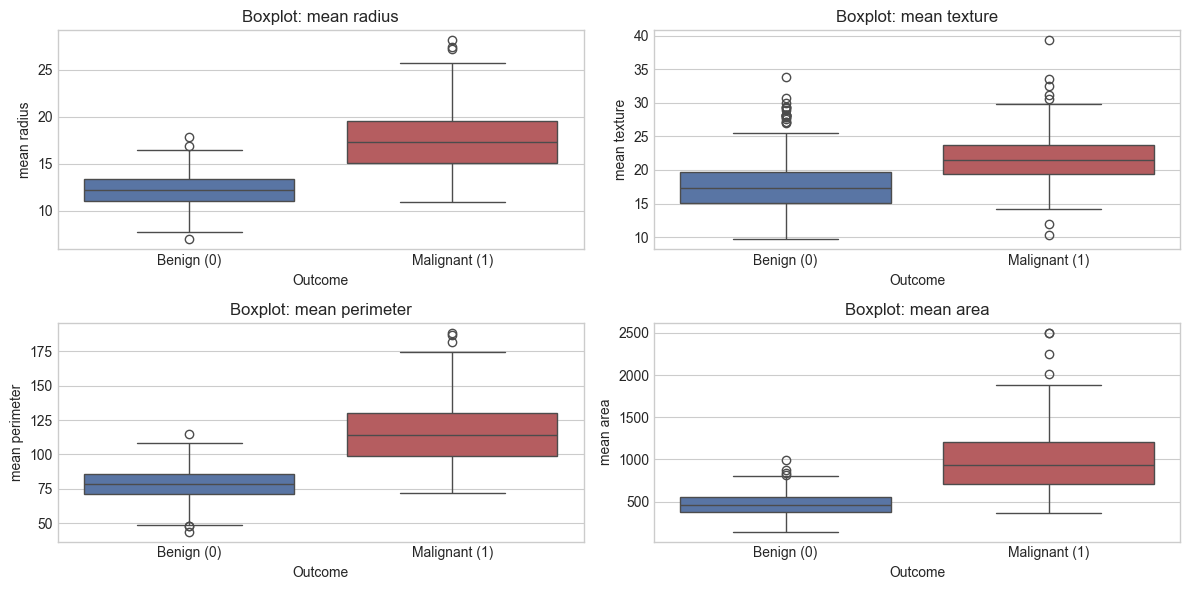

In [5]:
# Outlier visual inspection using Box Plots for key features
key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']

plt.figure(figsize=(12, 6))
for i, col in enumerate(key_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Outcome', y=col, data=df, palette=['#4C72B0', '#C44E52'])
    plt.xticks([0, 1], ['Benign (0)', 'Malignant (1)'])
    plt.title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()


**Observation on Missing Values, Duplicates & Outliers:**
- The dataset is complete with 0 missing values and 0 duplicate rows.
- Boxplots show extreme values/outliers in severe tumor cases (e.g., large `mean area`). Since these represent genuine physiological extremes in patients rather than recording errors, they are kept in the dataset.


### 4. Visualize the Data
- Class distribution plot
- Histograms of key features split by diagnosis
- Correlation heatmap of mean feature attributes


/var/folders/j9/dr8xhzc510z4w65q92f43hx00000gn/T/ipykernel_26039/2144054865.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Benign (0)', 'Malignant (1)'], y=[class_counts[0], class_counts[1]], ax=axes[0], palette=['#4C72B0', '#C44E52'])


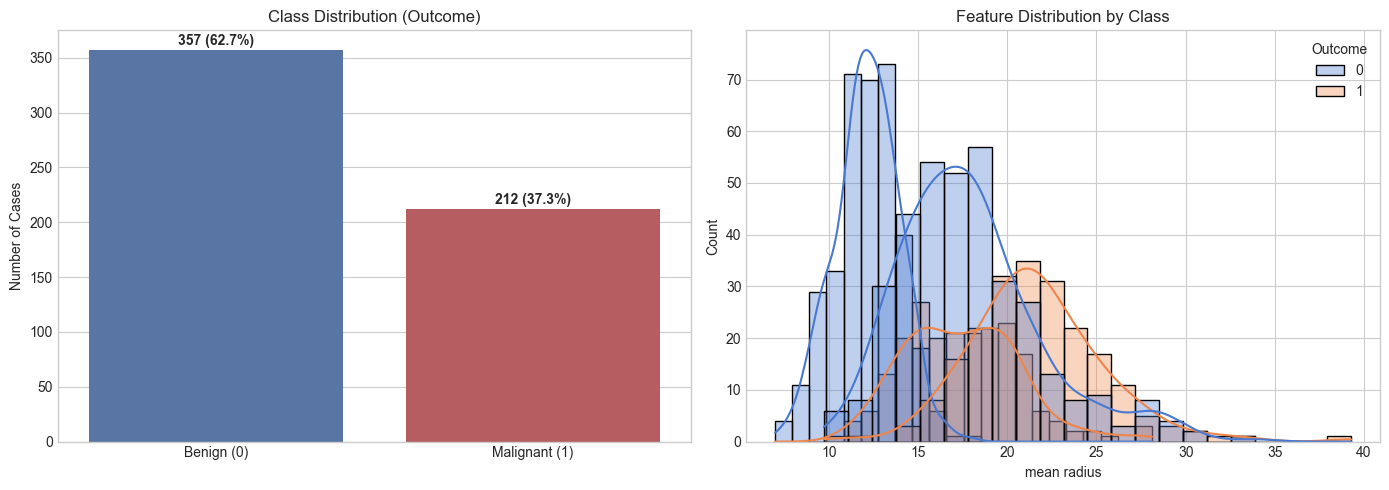

In [6]:
# Visualizing Class Distribution and Feature Histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class Distribution
class_counts = df['Outcome'].value_counts()
sns.barplot(x=['Benign (0)', 'Malignant (1)'], y=[class_counts[0], class_counts[1]], ax=axes[0], palette=['#4C72B0', '#C44E52'])
axes[0].set_title('Class Distribution (Outcome)')
axes[0].set_ylabel('Number of Cases')
for idx, count in enumerate([class_counts[0], class_counts[1]]):
    axes[0].text(idx, count + 5, f'{count} ({count/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Histograms
for feat in ['mean radius', 'mean texture']:
    sns.histplot(data=df, x=feat, hue='Outcome', kde=True, ax=axes[1], alpha=0.35)
axes[1].set_title('Feature Distribution by Class')

plt.tight_layout()
plt.show()


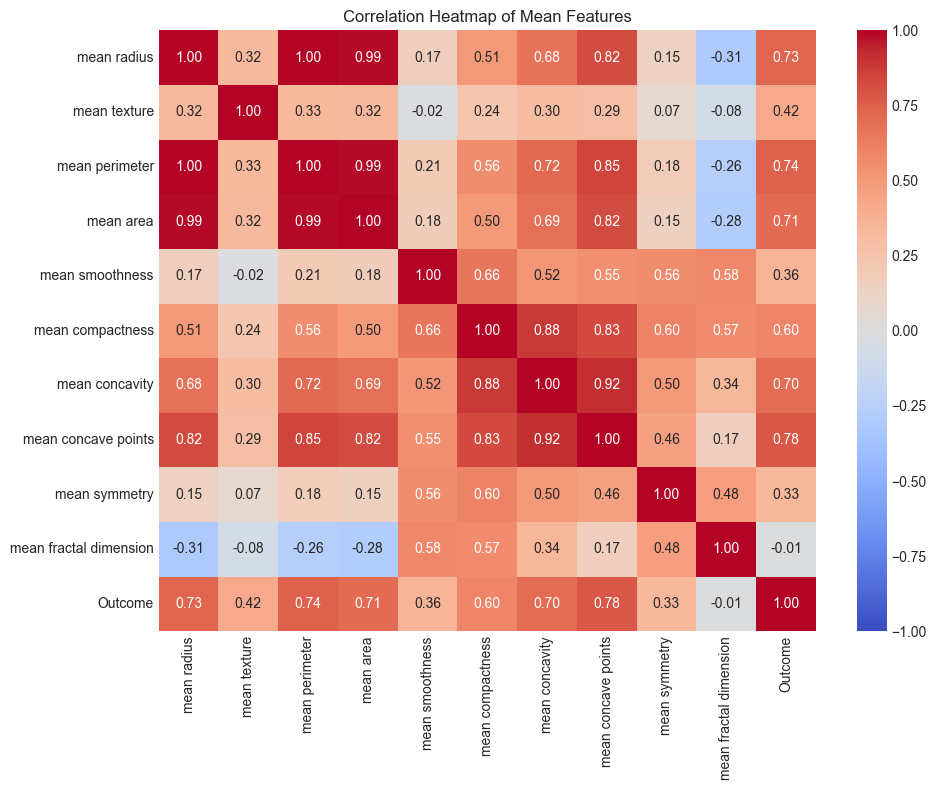

In [7]:
# Correlation Heatmap for Mean Features
mean_features = [col for col in df.columns if 'mean' in col] + ['Outcome']
plt.figure(figsize=(10, 8))
sns.heatmap(df[mean_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Mean Features')
plt.tight_layout()
plt.show()


### 5. Discussion on Class Imbalance and Model Training Implications
- **Class Counts:** 357 Benign (62.7%) vs. 212 Malignant (37.3%).
- **Implications:**
  - This reflects a moderate class imbalance (~60:40).
  - Evaluating purely on raw accuracy can mask high false negative rates if a classifier heavily favors the majority class.
  - Stratified sampling is essential during dataset splitting to keep the 60:40 ratio constant in both train and test sets.
  - Evaluation must focus heavily on **Recall** (Sensitivity) for the Malignant class to minimize missed diagnoses.


## Task 2: Data Preprocessing

### 1. Encode Target Variable
The target variable (`Outcome`) is represented as binary: `0` for Benign and `1` for Malignant.

### 2. Train-Test Split (80/20 Stratified Sampling)
We split the data into 80% training and 20% testing sets using `stratify=y` to preserve the target class distribution.


In [8]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# 80/20 Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).round(3))


Training set shape: (455, 30)
Testing set shape:  (114, 30)

Train class distribution:
Outcome
0    0.626
1    0.374
Name: proportion, dtype: float64

Test class distribution:
Outcome
0    0.632
1    0.368
Name: proportion, dtype: float64


### 3. Feature Standardization
Logistic Regression is sensitive to feature scaling because it fits a linear combination of features ($z = w^T x + b$). Features with larger ranges (like `mean area` in hundreds/thousands) would otherwise dominate model weights over smaller-scaled features (like `smoothness` < 0.1).

We apply `StandardScaler` to scale features to mean = 0 and variance = 1.


In [9]:
scaler = StandardScaler()

# Fit scaler on training set, transform train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display sample scaled values
pd.DataFrame(X_train_scaled, columns=X.columns).head(3).iloc[:, :5]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
0,0.518559,0.891826,0.424632,0.383925,-0.974744
1,-0.516364,-1.639710,-0.541349,-0.542961,0.476219
2,-0.368118,0.455515,-0.388250,-0.402970,-1.432979


## Task 3: Model Training and Basic Evaluation

### 1. Train Logistic Regression Model
Fitting a standard Logistic Regression model on the standardized training data.


In [10]:
# Initialize and train model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


### 2. Evaluate Model on Test Set
Metrics evaluated:
- Accuracy
- Precision, Recall, F1-Score (for both Benign and Malignant classes)
- Confusion Matrix Visualization
- ROC Curve and AUC Score


In [11]:
# Predict on test set
y_pred = lr_model.predict(X_test_scaled)
y_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"=== Overall Test Metrics ===")
print(f"Accuracy Score : {acc:.4f} ({acc*100:.2f}%)")
print(f"ROC AUC Score  : {auc:.4f}\n")

print("=== Classification Report (Both Classes) ===")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))


=== Overall Test Metrics ===
Accuracy Score : 0.9649 (96.49%)
ROC AUC Score  : 0.9960

=== Classification Report (Both Classes) ===
               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



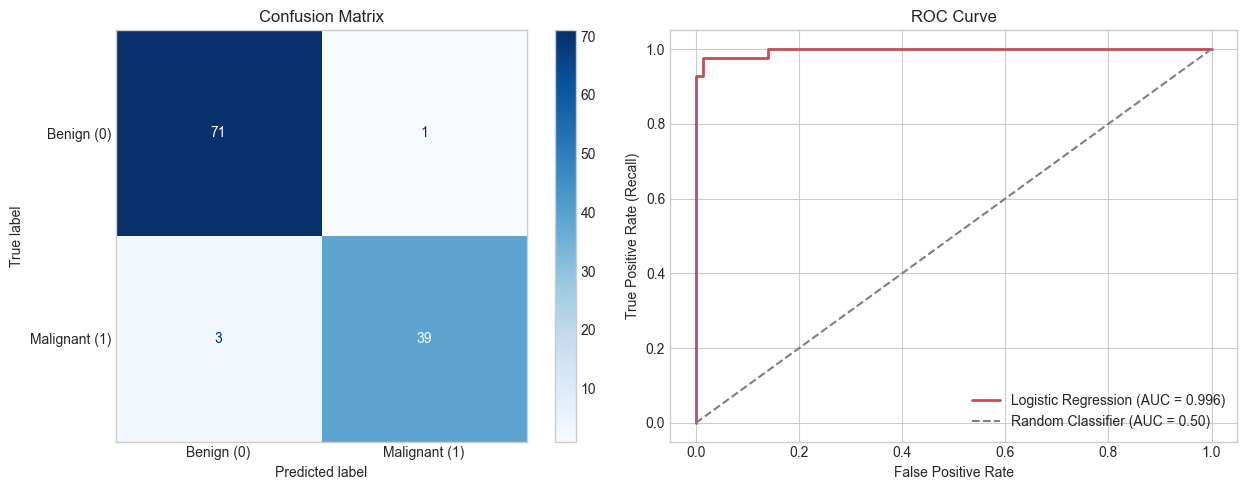

In [12]:
# Visualizing Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign (0)', 'Malignant (1)'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix')
axes[0].grid(False)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#C44E52', lw=2, label=f'Logistic Regression (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier (AUC = 0.50)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


### 3. Interpretation of Results (Medical Diagnosis Context)

#### Performance Metrics Breakdown:
- **Accuracy (96.49%):** Out of 114 test patients, 110 were correctly diagnosed.
- **Benign Class (0):** Precision = 96%, Recall = 99%, F1-Score = 0.97 (71 true negatives, 1 false positive).
- **Malignant Class (1):** Precision = 97%, Recall = 93%, F1-Score = 0.95 (39 true positives, 3 false negatives).
- **ROC AUC (0.996):** Demonstrates exceptional capability in distinguishing malignant from benign tumors.

#### Clinical Context Discussion:
1. **Critical Distinction Between Errors:**
   - **False Negative (3 cases):** Predicting benign when the patient actually has a malignant tumor. In healthcare, this is the worst-case error as it leads to untreated cancer progression.
   - **False Positive (1 case):** Predicting malignant when the patient has a benign tumor. This leads to additional testing (like a biopsy), causing emotional stress but avoiding fatal outcomes.

2. **Model Utility in Clinical Workflows:**
   - High **Recall (93%)** ensures that the vast majority of cancer cases are flagged immediately.
   - In a clinical screening pipeline, clinicians can adjust the classification threshold (e.g. lowering from 0.5 to ~0.3) to push Recall closer to 100%, prioritizing zero missed cancer cases.
